1. Load & schema check

2. Baseline (TF-IDF + NB)

3. DistilBERT fine-tune + eval + confusion matrix

4. 把 BERT 预测写回 df（用于后续主题/情绪分析）

5. spaCy：nouns / noun phrases（按 group 输出 top phrases）

6. VADER：sentiment score + 按 quarter/year/source/类别聚合

In [3]:
# ============================================================
# Integrated Pipeline: Classification (NB + DistilBERT) + Themes + Sentiment
# ============================================================

import os, re, sys, joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

In [4]:
# -----------------------------
# 0) Sanity check: running env
# -----------------------------
print("Python:", sys.executable)
print("Torch:", torch.__version__)

Python: /opt/anaconda3/envs/nlp-news/bin/python
Torch: 2.5.1


In [5]:
# -----------------------------
# 1) Config
# -----------------------------
CSV_PATH = "dataset_A_news_full_10500.csv"
TEXT_COL = "title"
LABEL_COL = "classes_str"

RANDOM_SEED = 42
TEST_SIZE = 0.2

TFIDF_MAX_FEATURES = 5000

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 64
NUM_EPOCHS = 3
TRAIN_BS = 4
EVAL_BS = 4
GRAD_ACCUM = 4

OUTPUT_DIR = "./results_integrated"
SAVE_MODEL_DIR = "./my_bert_model_integrated"
LABEL_ENCODER_PATH = "label_encoder.pkl"

In [7]:
# -----------------------------
# 2) Load data (DO THIS ONCE)
# -----------------------------

df = df = pd.read_csv("/Users/ziqiwei/Downloads/dataset_A_news_full_10500.csv")
df.columns = df.columns.astype(str).str.strip()

need = {TEXT_COL, LABEL_COL}
missing = need - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found: {list(df.columns)}")

df = df.dropna(subset=[LABEL_COL]).copy()
df[TEXT_COL] = df[TEXT_COL].astype(str).fillna("")
df[LABEL_COL] = df[LABEL_COL].astype(str).fillna("")

print("Rows:", len(df))
print("Num classes:", df[LABEL_COL].nunique())

Rows: 10500
Num classes: 392


In [8]:
# -----------------------------
# 3) Baseline preprocessing for TF-IDF
# -----------------------------
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

def preprocess_for_tfidf(text: str) -> str:
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", str(text).lower())
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

df["clean_text"] = df[TEXT_COL].apply(preprocess_for_tfidf)

In [9]:
# -----------------------------
# 4) Train/Val Split (robust stratify)
# -----------------------------
idx = np.arange(len(df))

# Count labels
label_counts = df[LABEL_COL].value_counts()

# Merge rare labels into OTHER_RARE
df["_label_for_split"] = df[LABEL_COL].where(df[LABEL_COL].map(label_counts) >= 2, "OTHER_RARE")

train_idx, val_idx = train_test_split(
    idx,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=df["_label_for_split"]
)

df_train = df.iloc[train_idx].copy()
df_val   = df.iloc[val_idx].copy()

print("Train:", len(df_train), "Val:", len(df_val))
print("Rare merged into OTHER_RARE:", (df["_label_for_split"] == "OTHER_RARE").sum())

# cleanup helper col if you want
# df.drop(columns=["_label_for_split"], inplace=True)

Train: 8400 Val: 2100
Rare merged into OTHER_RARE: 158


In [10]:
# ============================================================
# PART A) Baseline: TF-IDF + MultinomialNB
# ============================================================
print("\n" + "="*60)
print("A) Baseline: TF-IDF + MultinomialNB")
print("="*60)

tfidf = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES)
X_train_tfidf = tfidf.fit_transform(df_train["clean_text"])
X_val_tfidf   = tfidf.transform(df_val["clean_text"])

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, df_train[LABEL_COL])

nb_pred = nb_model.predict(X_val_tfidf)
print("NB Accuracy:", accuracy_score(df_val[LABEL_COL], nb_pred))
print(classification_report(df_val[LABEL_COL], nb_pred))

df_val["nb_pred"] = nb_pred


A) Baseline: TF-IDF + MultinomialNB
NB Accuracy: 0.47095238095238096
                                                                                                                                                                                            precision    recall  f1-score   support

                                                                                                                                                               Cognitive & Decision-Making       0.92      0.56      0.70        84
                                                                                                                            Cognitive & Decision-Making; Creativity, Expression & Identity       0.00      0.00      0.00         1
                                                                                           Cognitive & Decision-Making; Creativity, Expression & Identity; Learning, Knowledge & Education       0.00      0.00      0.00         1
                 

/opt/anaconda3/envs/nlp-news/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/nlp-news/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/nlp-news/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

In [17]:
# ============================================================
# PART B: DistilBERT Fine-tuning for News Classification
# ============================================================

import numpy as np
import torch
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# -----------------------------
# 1) Encode labels (string -> int)
# -----------------------------
le = LabelEncoder()
le.fit(df[LABEL_COL])

y_train_int = le.transform(df_train[LABEL_COL])
y_val_int   = le.transform(df_val[LABEL_COL])

num_labels = len(le.classes_)
print("Number of classes:", num_labels)

# -----------------------------
# 2) Tokenizer
# -----------------------------
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# -----------------------------
# 3) Dataset wrapper
# -----------------------------
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len
        )
        item = {k: torch.tensor(v) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = NewsDataset(df_train["title"], y_train_int, tokenizer)
val_dataset   = NewsDataset(df_val["title"],   y_val_int,   tokenizer)

# -----------------------------
# 4) Model
# -----------------------------
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

# -----------------------------
# 5) Metrics
# -----------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

# -----------------------------
# 6) Training arguments (CPU-safe)
# -----------------------------
training_args = TrainingArguments(
    output_dir="./bert_results",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    eval_strategy="epoch",          # ✅ CORRECT
    save_strategy="epoch",
    report_to="none",
    use_cpu=True,
    fp16=False
)


# -----------------------------
# 7) Trainer
# -----------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# -----------------------------
# 8) Train
# -----------------------------
trainer.train()

# -----------------------------
# 9) Evaluate
# -----------------------------
results = trainer.evaluate()
print("Validation results:", results)

preds = np.argmax(trainer.predict(val_dataset).predictions, axis=-1)
labels = list(range(len(le.classes_)))  # ensure full label set

print(classification_report(
    y_val_int,
    preds,
    labels=labels,
    target_names=le.classes_,
    zero_division=0
))




Number of classes: 392


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/ks/dv_7lkw93z38msf_9jp70flr0000gn/T/ipykernel_6458/4174335947.py:97: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,1.390200,1.285805,0.761905


Validation results: {'eval_loss': 1.2858054637908936, 'eval_accuracy': 0.7619047619047619, 'eval_runtime': 13.3598, 'eval_samples_per_second': 157.188, 'eval_steps_per_second': 39.297, 'epoch': 1.0}
                                                                                                                                                                                                        precision    recall  f1-score   support

                                                                                                                                                                           Cognitive & Decision-Making       0.84      1.00      0.91        84
                                                                                                                                        Cognitive & Decision-Making; Creativity, Expression & Identity       0.00      0.00      0.00         1
                                                                                


PART C) DistilBERT Evaluation Summary
Macro F1:     0.1064
Weighted F1:  0.6890

Classification report (may be long):
                                                                                                                                                                                                        precision    recall  f1-score   support

                                                                                                                                                                           Cognitive & Decision-Making       0.84      1.00      0.91        84
                                                                                                                                        Cognitive & Decision-Making; Creativity, Expression & Identity       0.00      0.00      0.00         1
                                                                                      Cognitive & Decision-Making; Creativity, Expression & Identity; Health, Sa

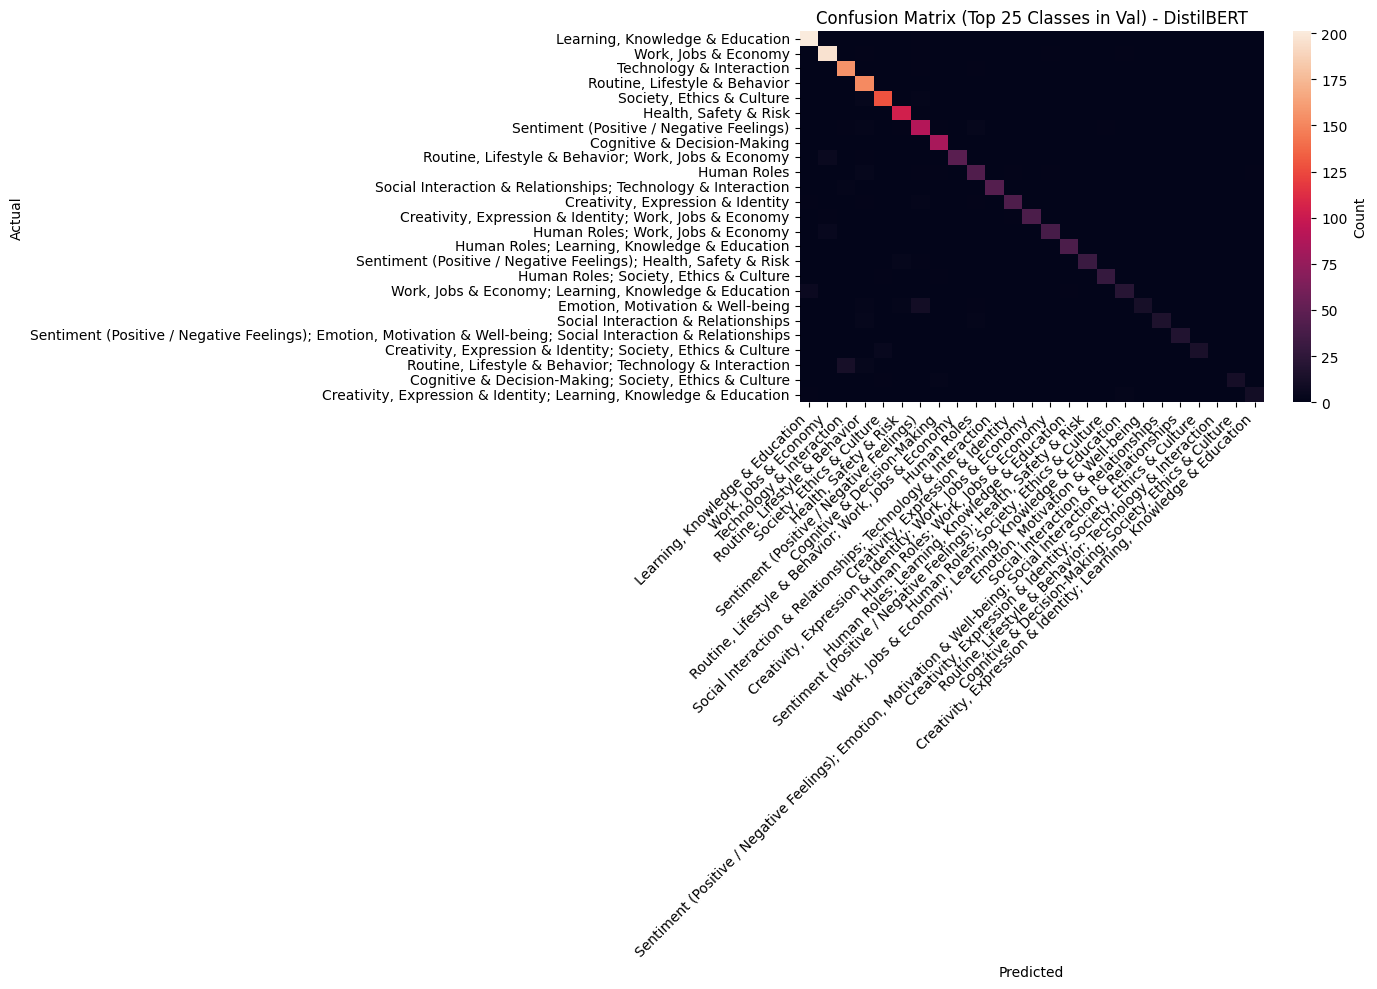


Top 10 Most Frequent Confusions (All Classes)
1. Actual: Routine, Lifestyle & Behavior; Technology & Interaction
   Pred:   Technology & Interaction
   Count:  12

2. Actual: Emotion, Motivation & Well-being
   Pred:   Sentiment (Positive / Negative Feelings)
   Count:  10

3. Actual: Human Roles; Health, Safety & Risk
   Pred:   Health, Safety & Risk
   Count:  7

4. Actual: Learning, Knowledge & Education; Health, Safety & Risk
   Pred:   Learning, Knowledge & Education
   Count:  7

5. Actual: Sentiment (Positive / Negative Feelings); Technology & Interaction
   Pred:   Technology & Interaction
   Count:  7

6. Actual: Cognitive & Decision-Making; Learning, Knowledge & Education
   Pred:   Learning, Knowledge & Education
   Count:  6

7. Actual: Routine, Lifestyle & Behavior; Learning, Knowledge & Education
   Pred:   Learning, Knowledge & Education
   Count:  6

8. Actual: Sentiment (Positive / Negative Feelings); Work, Jobs & Economy
   Pred:   Human Roles; Work, Jobs & Economy
 

In [19]:
# ============================================================
# PART C) Evaluation: Confusion Matrix + Top Confusions
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

# 1) Predictions on validation set
pred_out = trainer.predict(val_dataset)
val_preds = np.argmax(pred_out.predictions, axis=-1)
val_true  = np.array(y_val_int)

# 2) Summary metrics (useful for many-class, imbalanced data)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    val_true, val_preds, average="macro", zero_division=0
)
p_w, r_w, f1_w, _ = precision_recall_fscore_support(
    val_true, val_preds, average="weighted", zero_division=0
)

print("\n" + "="*60)
print("PART C) DistilBERT Evaluation Summary")
print("="*60)
print(f"Macro F1:     {f1_macro:.4f}")
print(f"Weighted F1:  {f1_w:.4f}")

# 3) Full classification report (safe: pass labels explicitly)
labels_all = list(range(len(le.classes_)))
print("\nClassification report (may be long):")
print(classification_report(
    val_true,
    val_preds,
    labels=labels_all,
    target_names=le.classes_,
    zero_division=0
))

# 4) Confusion matrix: show only TOP-N most frequent classes in val_true (readable)
TOP_N = 25  # change to 15/20/30 depending on readability

val_counts = pd.Series(val_true).value_counts()
top_labels = val_counts.head(TOP_N).index.tolist()

cm_top = confusion_matrix(val_true, val_preds, labels=top_labels)
top_names = [le.classes_[i] for i in top_labels]

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm_top,
    annot=False,
    fmt="d",
    xticklabels=top_names,
    yticklabels=top_names,
    cbar_kws={"label": "Count"}
)
plt.title(f"Confusion Matrix (Top {TOP_N} Classes in Val) - DistilBERT")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5) Top confusion pairs (off-diagonal) across ALL labels
cm_all = confusion_matrix(val_true, val_preds, labels=labels_all)
errors = cm_all.copy()
np.fill_diagonal(errors, 0)

flat_idx = np.argsort(errors.ravel())[::-1]
shown = 0
TOP_K_ERRORS = 10

print("\n" + "="*60)
print(f"Top {TOP_K_ERRORS} Most Frequent Confusions (All Classes)")
print("="*60)

for idx in flat_idx:
    if shown >= TOP_K_ERRORS:
        break
    i, j = np.unravel_index(idx, errors.shape)
    cnt = errors[i, j]
    if cnt == 0:
        break
    print(f"{shown+1}. Actual: {le.classes_[i]}")
    print(f"   Pred:   {le.classes_[j]}")
    print(f"   Count:  {cnt}\n")
    shown += 1

Part C — Confusion matrix (top-N) + top confusions + macro/weighted F1


Part C) DistilBERT Evaluation Summary
Accuracy:     0.7619
Macro F1:     0.1064
Weighted F1:  0.6890

Classification report (may be long):
                                                                                                                                                                                                        precision    recall  f1-score   support

                                                                                                                                                                           Cognitive & Decision-Making       0.84      1.00      0.91        84
                                                                                                                                        Cognitive & Decision-Making; Creativity, Expression & Identity       0.00      0.00      0.00         1
                                                                                      Cognitive & Decision-Making; Creativity, Expression &

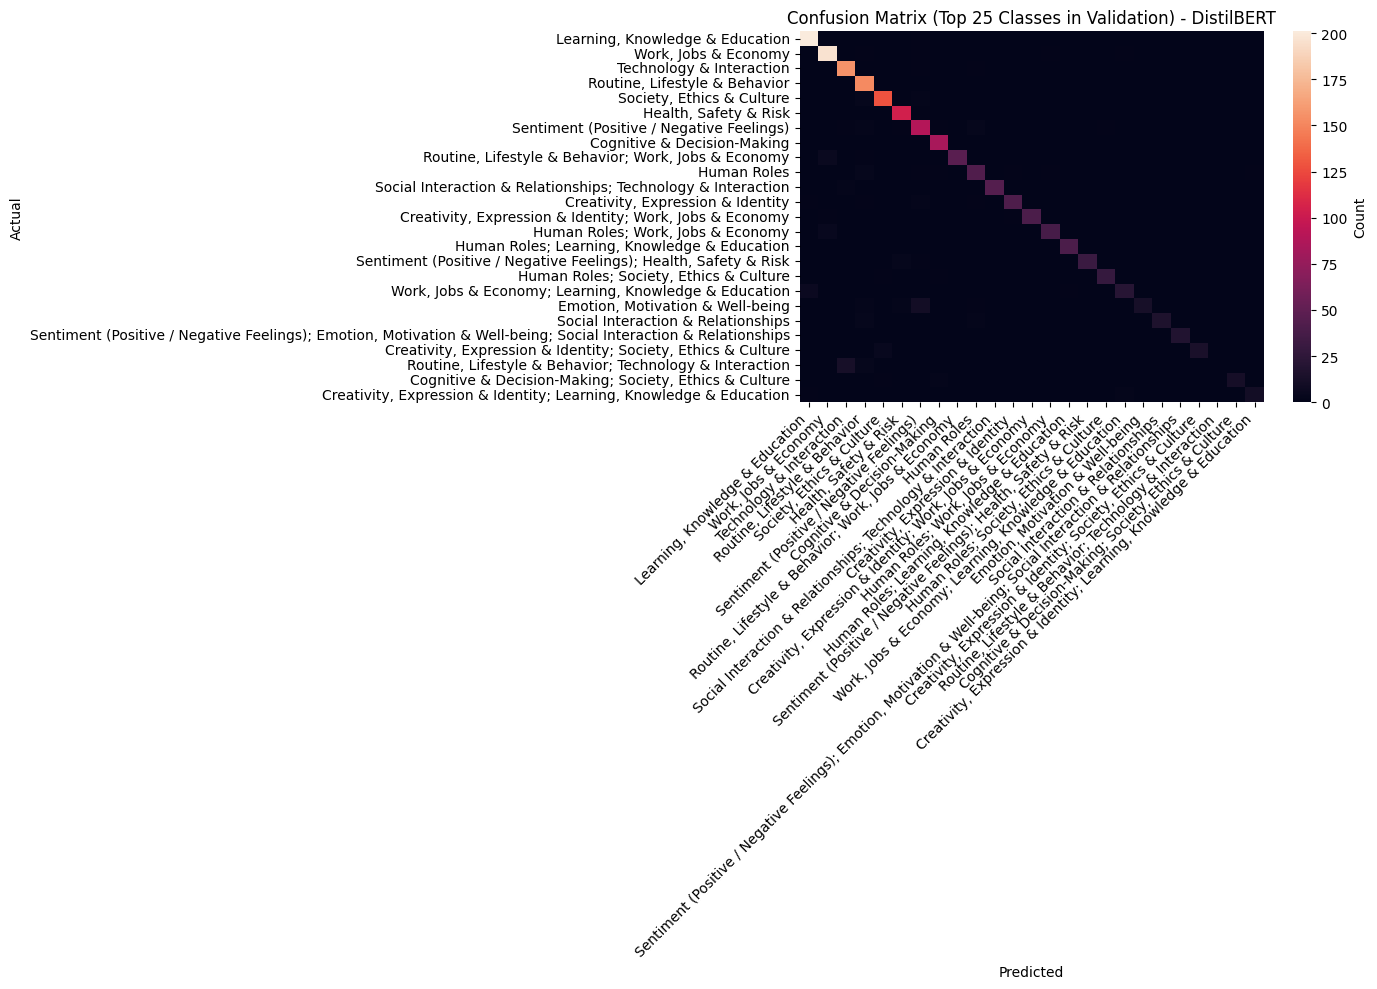


Top 10 Most Frequent Confusions (All Classes)
1. Actual: Routine, Lifestyle & Behavior; Technology & Interaction
   Pred:   Technology & Interaction
   Count:  12

2. Actual: Emotion, Motivation & Well-being
   Pred:   Sentiment (Positive / Negative Feelings)
   Count:  10

3. Actual: Human Roles; Health, Safety & Risk
   Pred:   Health, Safety & Risk
   Count:  7

4. Actual: Learning, Knowledge & Education; Health, Safety & Risk
   Pred:   Learning, Knowledge & Education
   Count:  7

5. Actual: Sentiment (Positive / Negative Feelings); Technology & Interaction
   Pred:   Technology & Interaction
   Count:  7

6. Actual: Cognitive & Decision-Making; Learning, Knowledge & Education
   Pred:   Learning, Knowledge & Education
   Count:  6

7. Actual: Routine, Lifestyle & Behavior; Learning, Knowledge & Education
   Pred:   Learning, Knowledge & Education
   Count:  6

8. Actual: Sentiment (Positive / Negative Feelings); Work, Jobs & Economy
   Pred:   Human Roles; Work, Jobs & Economy
 

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

# Predict on validation set
pred_out = trainer.predict(val_dataset)
val_preds = np.argmax(pred_out.predictions, axis=-1)
val_true  = np.array(y_val_int)

# Macro/Weighted F1 (more meaningful than accuracy for many classes)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    val_true, val_preds, average="macro", zero_division=0
)
p_w, r_w, f1_w, _ = precision_recall_fscore_support(
    val_true, val_preds, average="weighted", zero_division=0
)

print("\n" + "="*60)
print("Part C) DistilBERT Evaluation Summary")
print("="*60)
print(f"Accuracy:     {(val_true == val_preds).mean():.4f}")
print(f"Macro F1:     {f1_macro:.4f}")
print(f"Weighted F1:  {f1_w:.4f}")

# Full report (safe: force all labels)
labels_all = list(range(len(le.classes_)))
print("\nClassification report (may be long):")
print(classification_report(
    val_true, val_preds,
    labels=labels_all,
    target_names=le.classes_,
    zero_division=0
))

# Confusion matrix: only top-N frequent classes in val_true
TOP_N = 25
val_counts = pd.Series(val_true).value_counts()
top_labels = val_counts.head(TOP_N).index.tolist()

cm_top = confusion_matrix(val_true, val_preds, labels=top_labels)
top_names = [le.classes_[i] for i in top_labels]

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm_top,
    annot=False,
    xticklabels=top_names,
    yticklabels=top_names,
    cbar_kws={"label": "Count"}
)
plt.title(f"Confusion Matrix (Top {TOP_N} Classes in Validation) - DistilBERT")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Top-K confusions across all classes
cm_all = confusion_matrix(val_true, val_preds, labels=labels_all)
errors = cm_all.copy()
np.fill_diagonal(errors, 0)

flat_idx = np.argsort(errors.ravel())[::-1]
TOP_K_ERRORS = 10

print("\n" + "="*60)
print(f"Top {TOP_K_ERRORS} Most Frequent Confusions (All Classes)")
print("="*60)

shown = 0
for idx in flat_idx:
    if shown >= TOP_K_ERRORS:
        break
    i, j = np.unravel_index(idx, errors.shape)
    cnt = errors[i, j]
    if cnt == 0:
        break
    print(f"{shown+1}. Actual: {le.classes_[i]}")
    print(f"   Pred:   {le.classes_[j]}")
    print(f"   Count:  {cnt}\n")
    shown += 1


In [20]:
# ============================================================
# PART D) Attach Predictions to DataFrame for Error Analysis
# ============================================================
import pandas as pd
import numpy as np

# If you created df_val earlier via train_idx/val_idx split:
# df_val must exist. If not, recreate it using your val_idx.

df_val = df_val.copy()

df_val["true_label_id"] = val_true
df_val["pred_label_id"] = val_preds
df_val["true_label"] = le.inverse_transform(df_val["true_label_id"])
df_val["pred_label"] = le.inverse_transform(df_val["pred_label_id"])
df_val["correct"] = (df_val["true_label_id"] == df_val["pred_label_id"])

# confidence = max softmax probability
import torch
probs = torch.softmax(torch.tensor(pred_out.predictions), dim=-1).numpy()
df_val["pred_confidence"] = probs.max(axis=1)

print("Val accuracy (recomputed):", df_val["correct"].mean())

# Show worst confident mistakes (high confidence but wrong)
worst = df_val[df_val["correct"] == False].sort_values("pred_confidence", ascending=False)
display(worst[[TEXT_COL, LABEL_COL, "true_label", "pred_label", "pred_confidence"]].head(20))

# Save to artifacts folder if you set it; otherwise saves in current folder
OUT_CSV = "val_predictions_distilbert.csv"
df_val.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)


Val accuracy (recomputed): 0.7619047619047619


,title,classes_str,true_label,pred_label,pred_confidence
6706,Update: Chinese government proposes creation o...,"Creativity, Expression & Identity; Society, Et...","Creativity, Expression & Identity; Society, Et...","Society, Ethics & Culture",0.986247
5778,A musician with Charleston ties got called AI....,"Human Roles; Work, Jobs & Economy","Human Roles; Work, Jobs & Economy","Work, Jobs & Economy",0.985634
129,How Agentic AI is tackling the mundane and ess...,"Routine, Lifestyle & Behavior; Work, Jobs & Ec...","Routine, Lifestyle & Behavior; Work, Jobs & Ec...","Work, Jobs & Economy",0.985430
3900,Stop using AI for these 9 work tasks - here's why,"Routine, Lifestyle & Behavior; Work, Jobs & Ec...","Routine, Lifestyle & Behavior; Work, Jobs & Ec...","Work, Jobs & Economy",0.982395
6260,"From Metaverse to Machine Learning, Inside Met...","Learning, Knowledge & Education; Technology & ...","Learning, Knowledge & Education; Technology & ...","Learning, Knowledge & Education",0.982331
5365,From Curious to Confident: NAB Dives into 40+ ...,Sentiment (Positive / Negative Feelings); Lear...,Sentiment (Positive / Negative Feelings); Lear...,"Learning, Knowledge & Education",0.982139
479,Sal Khan is hopeful that AI won’t destroy educ...,Sentiment (Positive / Negative Feelings); Lear...,Sentiment (Positive / Negative Feelings); Lear...,"Learning, Knowledge & Education",0.981843
9416,"Managers are using AI to assess raises, promot...","Work, Jobs & Economy; Learning, Knowledge & Ed...","Work, Jobs & Economy; Learning, Knowledge & Ed...","Learning, Knowledge & Education",0.981809
5030,New Study Shows AI Is AI Biased Toward AI. 10 ...,"Routine, Lifestyle & Behavior; Learning, Knowl...","Routine, Lifestyle & Behavior; Learning, Knowl...","Learning, Knowledge & Education",0.981353
4412,FSO and Microsoft join forces to accelerate AI...,"Work, Jobs & Economy; Learning, Knowledge & Ed...","Work, Jobs & Economy; Learning, Knowledge & Ed...","Learning, Knowledge & Education",0.981100


Saved: val_predictions_distilbert.csv


Part D — Attach predictions + confidence to df_val and export

In [25]:
import torch

df_val = df_val.copy()

df_val["true_label_id"] = val_true
df_val["pred_label_id"] = val_preds
df_val["true_label"] = le.inverse_transform(df_val["true_label_id"])
df_val["pred_label"] = le.inverse_transform(df_val["pred_label_id"])
df_val["correct"] = (df_val["true_label_id"] == df_val["pred_label_id"])

# Confidence = max softmax prob
probs = torch.softmax(torch.tensor(pred_out.predictions), dim=-1).numpy()
df_val["pred_confidence"] = probs.max(axis=1)

print("Validation accuracy (recomputed):", df_val["correct"].mean())

# Show high-confidence mistakes (useful for discussion section)
worst = df_val[df_val["correct"] == False].sort_values("pred_confidence", ascending=False)
display(worst[[TEXT_COL, LABEL_COL, "true_label", "pred_label", "pred_confidence"]].head(20))

OUT_CSV = "val_predictions_distilbert.csv"
df_val.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)


Validation accuracy (recomputed): 0.7619047619047619


,title,classes_str,true_label,pred_label,pred_confidence
6706,Update: Chinese government proposes creation o...,"Creativity, Expression & Identity; Society, Et...","Creativity, Expression & Identity; Society, Et...","Society, Ethics & Culture",0.986247
5778,A musician with Charleston ties got called AI....,"Human Roles; Work, Jobs & Economy","Human Roles; Work, Jobs & Economy","Work, Jobs & Economy",0.985634
129,How Agentic AI is tackling the mundane and ess...,"Routine, Lifestyle & Behavior; Work, Jobs & Ec...","Routine, Lifestyle & Behavior; Work, Jobs & Ec...","Work, Jobs & Economy",0.985430
3900,Stop using AI for these 9 work tasks - here's why,"Routine, Lifestyle & Behavior; Work, Jobs & Ec...","Routine, Lifestyle & Behavior; Work, Jobs & Ec...","Work, Jobs & Economy",0.982395
6260,"From Metaverse to Machine Learning, Inside Met...","Learning, Knowledge & Education; Technology & ...","Learning, Knowledge & Education; Technology & ...","Learning, Knowledge & Education",0.982331
5365,From Curious to Confident: NAB Dives into 40+ ...,Sentiment (Positive / Negative Feelings); Lear...,Sentiment (Positive / Negative Feelings); Lear...,"Learning, Knowledge & Education",0.982139
479,Sal Khan is hopeful that AI won’t destroy educ...,Sentiment (Positive / Negative Feelings); Lear...,Sentiment (Positive / Negative Feelings); Lear...,"Learning, Knowledge & Education",0.981843
9416,"Managers are using AI to assess raises, promot...","Work, Jobs & Economy; Learning, Knowledge & Ed...","Work, Jobs & Economy; Learning, Knowledge & Ed...","Learning, Knowledge & Education",0.981809
5030,New Study Shows AI Is AI Biased Toward AI. 10 ...,"Routine, Lifestyle & Behavior; Learning, Knowl...","Routine, Lifestyle & Behavior; Learning, Knowl...","Learning, Knowledge & Education",0.981353
4412,FSO and Microsoft join forces to accelerate AI...,"Work, Jobs & Economy; Learning, Knowledge & Ed...","Work, Jobs & Economy; Learning, Knowledge & Ed...","Learning, Knowledge & Education",0.981100


Saved: val_predictions_distilbert.csv


In [21]:
# ============================================================
# PART E) Inference: Predict Top-K classes for a new title
# ============================================================
import numpy as np
import torch

@torch.no_grad()
def predict_top_k(title: str, top_k: int = 5):
    model.eval()
    enc = tokenizer(
        str(title),
        truncation=True,
        padding=True,
        max_length=64,
        return_tensors="pt"
    )
    enc = {k: v.to(model.device) for k, v in enc.items()}
    out = model(**enc)
    probs = torch.softmax(out.logits, dim=-1).squeeze(0).cpu().numpy()

    top_idx = probs.argsort()[::-1][:top_k]
    return [(le.classes_[i], float(probs[i])) for i in top_idx]

test_title = "New AI technology improves medical diagnosis accuracy"
print("Input:", test_title)
for lbl, p in predict_top_k(test_title, top_k=5):
    print(f"{lbl}: {p*100:.2f}%")


Input: New AI technology improves medical diagnosis accuracy
Technology & Interaction: 47.40%
Society, Ethics & Culture; Technology & Interaction: 3.79%
Health, Safety & Risk: 2.35%
Health, Safety & Risk; Technology & Interaction: 2.31%
Social Interaction & Relationships; Technology & Interaction: 2.28%


Part E — Inference: top-k predictions for a new title

In [26]:
import torch
import numpy as np

@torch.no_grad()
def predict_top_k(title: str, top_k: int = 5):
    model.eval()
    enc = tokenizer(
        str(title),
        truncation=True,
        padding=True,
        max_length=64,
        return_tensors="pt"
    )
    enc = {k: v.to(model.device) for k, v in enc.items()}
    out = model(**enc)
    probs = torch.softmax(out.logits, dim=-1).squeeze(0).cpu().numpy()

    top_idx = probs.argsort()[::-1][:top_k]
    return [(le.classes_[i], float(probs[i])) for i in top_idx]

test_title = "New AI technology improves medical diagnosis accuracy"
print("Input:", test_title)
for lbl, p in predict_top_k(test_title, top_k=5):
    print(f"{lbl}: {p*100:.2f}%")


Input: New AI technology improves medical diagnosis accuracy
Technology & Interaction: 47.40%
Society, Ethics & Culture; Technology & Interaction: 3.79%
Health, Safety & Risk: 2.35%
Health, Safety & Risk; Technology & Interaction: 2.31%
Social Interaction & Relationships; Technology & Interaction: 2.28%


In [27]:
print(type(df_val), df_val.shape)
print(len(y_val_int), len(val_dataset))

print(type(df_val), df_val.shape)
print("y_val_int length:", len(y_val_int))
print("val_dataset length:", len(val_dataset))


<class 'pandas.core.frame.DataFrame'> (2100, 21)
2100 2100
<class 'pandas.core.frame.DataFrame'> (2100, 21)
y_val_int length: 2100
val_dataset length: 2100
